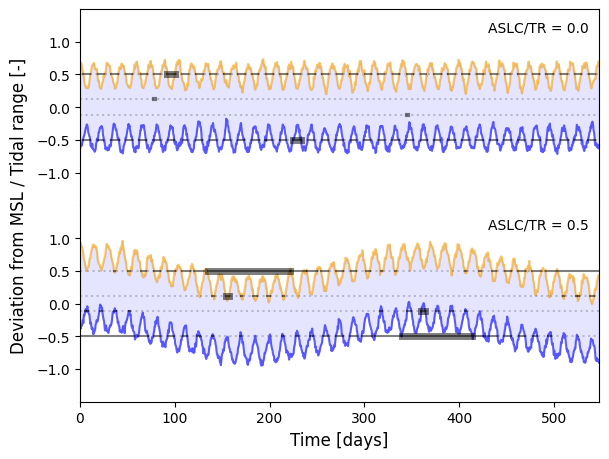

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

# path_root = "/Users/timhermans/Documents/GitHub/aslc_intertidal"
path_root = "F:/collaborations/Tim_Hermans/aslc_intertidal"
os.chdir(path_root)

import src.functions as f

def plot_panel(ax, amplitude_annual_cycle):

    def find_events(x):
        x = x.astype(int)
        x = np.pad(x, ((1,1)), constant_values = 0)

        # Find change points
        changes = np.diff(x)

        start = np.where(changes ==  1)[0]
        end   = np.where(changes == -1)[0]

        return start, end
    
    dt, n_years, sigma, rho = 5/60, 1.5, 0.013, 0.079
    elevation = np.arange(-3,3,0.01)

    _, waterlevel, _ = f.create_waterlevel_timeseries(amplitude_annual_cycle = amplitude_annual_cycle, mean_waterlevel = 0., dt = dt, n_years = n_years, sigma = sigma, rho = rho)
    tidal_cycle, low_waterlevel, high_waterlevel = f.calculate_highlow_water(waterlevel, plot = False)   
    time = 365*tidal_cycle/705     
    ax.plot(time, low_waterlevel, c = 'blue', alpha = 0.6, label = 'High water level')
    ax.plot(time, high_waterlevel, c = 'orange', alpha = 0.6, label = 'Low water level')
    ax.fill_between(time, low_waterlevel, high_waterlevel, color = (0,0,1,0.1))

    for z in [-0.5,-0.12,0.12,0.5]:

        start, end = find_events(high_waterlevel < z)
        if start.size > 0:
            duration = end - start
            ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (0,0,0,0.5), lw = 5)
            for i in range(start.size):
                ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

        start, end = find_events(low_waterlevel > z)
        if start.size > 0:
            duration = end - start
            ax.plot([time[start[np.argmax(duration)]], time[end[np.argmax(duration)]-1]], [z, z], c = (0,0,0,0.5), lw = 5)
            for i in range(start.size):
                ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.5))

        start, end = find_events((low_waterlevel < z) & (high_waterlevel > z))
        if start.size > 0:
            for i in range(start.size):
                ax.plot([time[start[i]], time[end[i]-1]], [z, z], c = (0,0,0,0.2), linestyle = 'dotted')

        if (amplitude_annual_cycle == 0) & ((z == -0.12) | (z == 0.12)):
            r = np.random.choice(time.size, size = 1)
            plt.plot([time[r],time[r+2]], [z,z], lw = 3, c = (0,0,0,0.5))

            
    # ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.set_xlabel('Time [days]', fontsize = 12)
    ax.set_yticks(ticks = [-1, -0.5, 0, 0.5, 1])
    ax.set_xlim(0, 365*1.5)
    ax.set_ylim(-1.5, 1.5)

def figure_1_multipanel(path_png = None):

    np.random.seed(1234567)

    rows, cols = 2, 1
    fig = plt.figure(figsize=((6.4 + 0.3)*cols,(2.4 + 0.15)*rows))
    gs1 = fig.add_gridspec(rows, cols, hspace = .0, wspace = .15) #define subplot grid

    ax = fig.add_subplot(gs1[0,0])
    plot_panel(ax, amplitude_annual_cycle = 0.0)
    ax.set_xticks([])
    ax.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.0', horizontalalignment = 'right')
    ax.spines['bottom'].set_visible(False)

    ax = fig.add_subplot(gs1[1,0])
    plot_panel(ax, amplitude_annual_cycle = 0.5)
    ax.set_ylabel('Deviation from MSL / Tidal range [-]', fontsize = 12)
    ax.yaxis.set_label_coords(-0.1,1)
    ax.text(x = 365*1.47, y = 1.15, s = 'ASLC/TR = 0.5', horizontalalignment = 'right')
    ax.spines['top'].set_visible(False)

    if path_png is not None:
        plt.savefig(path_png, dpi = 300, bbox_inches = "tight", pad_inches = 0.2)
    plt.show()

figure_1_multipanel(path_png = './figures/figure_2/figure_2a.png')